# Ms. Pac-Man DQN Agent — Class 3 Assignment

This notebook trains a Deep Q-Network (DQN) to play Atari **Ms. Pac-Man**, following the assignment spec:

- Chooses **exploration rate**, **episode count**, and **learning rate** as the three required hyperparameters (see the *Hyperparameters* cell below — clearly marked).
- Records an **untrained** and a **trained** gameplay GIF.
- Plots **score, loss, and exploration** across training.
- Reports **5 baseline** and **5 trained** evaluation scores (same 5 seeds, same 5% exploration, same time limit, both times) with means.
- Saves **intermediate GIFs and checkpoints** every 50 episodes (training runs well past the 25-episode threshold that triggers this requirement).

**On top of plain DQN**, this notebook adds three lightweight, well-established upgrades (Double DQN, a Dueling network architecture, and reward scaling instead of hard clipping) — all validated on Ms. Pac-Man in the original research, and all added because they improve *how well* the agent learns, not just *how long* it trains. See the markdown cell above the network definition for why.

**How to run this:** Runtime → Change runtime type → select a GPU (T4 is fine) → Runtime → Run all. Expect roughly 1–2 hours end to end. Every code cell has a plain-language comment explaining what it does.


In [1]:
# --- Install packages not already in the Colab image ---
# (torch and opencv usually ship with Colab already; this is safe to re-run either way)
!pip install -q "gymnasium[atari]" ale-py stable-baselines3 imageio opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 14.4 MB/s eta 0:00:00


In [2]:
# --- Imports & device setup ---
import os
import random
import time
from collections import deque

import ale_py
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from stable_baselines3.common.atari_wrappers import AtariWrapper

gym.register_envs(ale_py)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type != "cuda":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > GPU, then Runtime > Restart and run all.")

# Where we'll save everything this notebook produces, so it can be zipped up
# and committed to the GitHub repo afterward.
OUTPUT_DIR = "outputs"
GIF_DIR = os.path.join(OUTPUT_DIR, "gifs")
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
for d in (GIF_DIR, CKPT_DIR, PLOT_DIR):
    os.makedirs(d, exist_ok=True)


Using device: cuda


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Hyperparameters

These are the **three hyperparameters the assignment requires us to choose**, plus a short justification for each:

- **`LEARNING_RATE`** — how big a step the network takes each time it updates its beliefs. We use the assignment's own suggested reference value (`0.0001`), which is also the standard value used in the original DQN research for Atari games — a reasonable, well-tested starting point rather than an arbitrary guess.
- **`EXPLORATION`** — the *post-warmup* random-action frequency (per the assignment's own definition). We start at 100% random (`1.0`) and linearly anneal down to this floor over the first `EPSILON_DECAY_EPISODES` episodes, then hold it steady. `0.1` (10%) is a common default that balances continuing to discover new strategies against actually using what's been learned.
- **`EPISODES`** — how many full training games to play. We target `250`, chosen to fit a ~1-2 hour Colab session (see the *Efficiency upgrades* note below on why a modest, not dramatic, improvement is the honest expectation at this scale).

Everything else below is a **supporting setting**, not one of the three graded hyperparameters — but each is deliberately scaled down (~10x) from the "textbook" DQN defaults, because those defaults assume millions of training frames. At our scale, using the textbook defaults would mean the replay buffer and target network never really kick in before training ends.


In [3]:
# --- The three required hyperparameters ---
LEARNING_RATE = 0.0001   # reference value suggested by the assignment
EXPLORATION = 0.1        # post-warmup random-action frequency
EPISODES = 250           # training episodes (see markdown above for reasoning)

# --- Supporting settings (scaled down ~10x from full-scale DQN defaults for a short run) ---
EPSILON_START = 1.0
EPSILON_DECAY_EPISODES = 150     # anneal from EPSILON_START down to EXPLORATION over this many episodes
GAMMA = 0.99                     # how much future reward matters vs. immediate reward
BATCH_SIZE = 32
REPLAY_BUFFER_CAPACITY = 20_000  # vs. ~1,000,000 in full-scale DQN
WARMUP_STEPS = 2_000             # steps of pure random play before learning starts, vs. ~50,000 full-scale
TARGET_UPDATE_EVERY_STEPS = 750  # vs. ~10,000 full-scale
N_STACK = 4                      # how many recent frames the network sees at once (lets it perceive motion)
REWARD_SCALE = 100.0             # divide raw game points by this instead of clipping to -1/0/+1 (see note below)
CHECKPOINT_EVERY_EPISODES = 50   # intermediate GIF + checkpoint cadence (assignment requires this once episodes > 25)

# --- Evaluation settings: MUST stay identical between baseline and post-training eval ---
EVAL_SEEDS = [0, 1, 2, 3, 4]
EVAL_EXPLORATION = 0.05          # per assignment spec: keep a small residual exploration during eval
EVAL_MAX_STEPS = 10_000          # hard cap per eval episode so a stuck run can't hang the notebook

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)


## Environment setup

Two environment configurations, built from the same wrappers:

- **Training environment**: ends an episode as soon as Pac-Man loses a life (`terminal_on_life_loss=True`). This is a standard DQN training trick — it gives the network more frequent, clearer learning signal (dying is an unambiguous bad outcome) rather than waiting through all 3 lives before it gets feedback.
- **Evaluation environment**: plays the **full game, all 3 lives** (`terminal_on_life_loss=False`). This matters because the assignment's "score" — and the leaderboard/professor's ~300-point reference — means the total score across a whole game, not just one life. Using the training-style environment for evaluation would silently under-report the real score.

Both use the same underlying preprocessing (grayscale, resized to 84x84, 4 stacked frames) via Stable-Baselines3's proven `AtariWrapper`, reused here just for its preprocessing — not its training loop, so our own training loop below stays fully visible and editable.

Reward scaling: standard DQN clips every reward to exactly -1, 0, or +1, which would make eating a 10-point dot look identical to eating a 1600-point ghost. We instead divide raw rewards by `REWARD_SCALE` — this keeps the *relative* size of rewards intact (important in Ms. Pac-Man specifically) while still keeping the numbers small enough for stable learning.


In [4]:
def make_env(training: bool, render_mode=None):
    env = gym.make("ALE/MsPacman-v5", render_mode=render_mode)
    env = AtariWrapper(env, clip_reward=False, terminal_on_life_loss=training)
    env = gym.wrappers.FrameStackObservation(env, stack_size=N_STACK)
    return env


def preprocess(obs):
    # (4, 84, 84, 1) uint8 -> (4, 84, 84) float32 scaled to [0, 1]
    return np.asarray(obs, dtype=np.float32).squeeze(-1) / 255.0


## The network: Dueling architecture + Double DQN

**Dueling architecture**: instead of one output per action, the network splits into a *value* stream (how good is this situation, period) and an *advantage* stream (how much better is each specific move than average, right now). They're recombined into the final action values. This learns faster in states where most moves are equally fine and only one or two really matter — a very common situation in Ms. Pac-Man (e.g., only the move away from a nearby ghost matters; the others are all "fine").

**Double DQN** (used in the training loop below, not here): normal DQN tends to be overly optimistic about how good its own choices are, because the same network both *picks* the best next move and *judges* how good that move is — errors compound. Double DQN fixes this by having the *online* network pick the move and the separate, slower-moving *target* network judge it.


In [5]:
class DuelingQNetwork(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(N_STACK, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
        )
        with torch.no_grad():
            conv_out_size = self.conv(torch.zeros(1, N_STACK, 84, 84)).flatten(1).shape[1]

        self.value_head = nn.Sequential(nn.Linear(conv_out_size, 512), nn.ReLU(), nn.Linear(512, 1))
        self.advantage_head = nn.Sequential(nn.Linear(conv_out_size, 512), nn.ReLU(), nn.Linear(512, n_actions))

    def forward(self, x):
        features = self.conv(x).flatten(1)
        value = self.value_head(features)
        advantage = self.advantage_head(features)
        # Recombine: subtracting the mean advantage keeps value/advantage identifiable
        # (otherwise the split is ambiguous - infinitely many value/advantage pairs give the same Q).
        return value + (advantage - advantage.mean(dim=1, keepdim=True))


In [6]:
class ReplayBuffer:
    """Stores past experience so the network can learn from a random mix of old
    and new moments, instead of only the most recent (highly correlated) ones."""

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.int64, device=DEVICE),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return len(self.buffer)


def epsilon_greedy_action(q_net, state, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return int(torch.argmax(q_net(state_t), dim=1).item())


def double_dqn_loss(online_net, target_net, batch, gamma):
    states, actions, rewards, next_states, dones = batch
    q_values = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        # Double DQN: online net picks the action, target net judges its value.
        next_actions = online_net(next_states).argmax(dim=1)
        next_q = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
        target = rewards + gamma * next_q * (1.0 - dones)
    return F.smooth_l1_loss(q_values, target)


## Evaluation function

One function, used identically for the baseline (untrained) and post-training evaluation, so the comparison is fair. It always uses the **same 5 seeds**, the **same 5% exploration**, and the **same step cap** — per the assignment's explicit requirement to keep these unchanged before and after training. It can optionally record one of the runs as a GIF.


In [7]:
def evaluate_agent(q_net, seeds, epsilon, max_steps, record_seed=None, gif_path=None):
    """Runs one full (all-lives) game per seed and returns the list of scores.
    If record_seed is given, also saves a GIF of that one seed's game."""
    scores = []
    for seed in seeds:
        render_mode = "rgb_array" if (record_seed is not None and seed == record_seed) else None
        env = make_env(training=False, render_mode=render_mode)
        obs, info = env.reset(seed=seed)
        state = preprocess(obs)
        frames = [env.render()] if render_mode else None

        total_reward = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = epsilon_greedy_action(q_net, state, epsilon, env.action_space.n)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            state = preprocess(obs)
            total_reward += reward
            steps += 1
            if frames is not None:
                frames.append(env.render())

        if frames is not None and gif_path is not None:
            imageio.mimsave(gif_path, frames, fps=30)

        scores.append(total_reward)
        env.close()
    return scores


## Baseline evaluation (untrained network)

Before any training, we evaluate the freshly-initialized (essentially random) network on the 5 fixed seeds, and save a GIF of one of those games. This is our "before" measurement.


In [8]:
sample_env = make_env(training=False)
N_ACTIONS = sample_env.action_space.n
sample_env.close()

online_net = DuelingQNetwork(N_ACTIONS).to(DEVICE)
target_net = DuelingQNetwork(N_ACTIONS).to(DEVICE)
target_net.load_state_dict(online_net.state_dict())
optimizer = torch.optim.Adam(online_net.parameters(), lr=LEARNING_RATE)
replay_buffer = ReplayBuffer(REPLAY_BUFFER_CAPACITY)

baseline_scores = evaluate_agent(
    online_net, EVAL_SEEDS, EVAL_EXPLORATION, EVAL_MAX_STEPS,
    record_seed=EVAL_SEEDS[0], gif_path=os.path.join(GIF_DIR, "baseline_untrained.gif"),
)
print("Baseline (untrained) scores:", baseline_scores)
print("Baseline mean score:", np.mean(baseline_scores))


/usr/local/lib/python3.13/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Baseline (untrained) scores: [110.0, 110.0, 120.0, 130.0, 90.0]
Baseline mean score: 112.0


## Training

Standard DQN training loop, with Double DQN's target computation and the Dueling network defined above. Progress prints every 10 episodes, including a rough time estimate for the full run so you can tell early on whether `EPISODES` needs adjusting.

Every `CHECKPOINT_EVERY_EPISODES` (50) episodes, we save the model weights and a gameplay GIF — this is the assignment's "intermediate GIFs and checkpoints" requirement for runs past 25 episodes.


In [9]:
episode_scores = []   # training-env score per episode (ends on first life lost - see note below)
episode_losses = []
episode_epsilons = []

total_steps = 0
start_time = time.time()

for episode in range(EPISODES):
    # Linear anneal from EPSILON_START down to EXPLORATION, then hold steady.
    decay_progress = min(1.0, episode / max(1, EPSILON_DECAY_EPISODES))
    epsilon = EPSILON_START + decay_progress * (EXPLORATION - EPSILON_START)

    env = make_env(training=True)
    obs, info = env.reset(seed=1000 + episode)  # distinct from eval seeds (0-4)
    state = preprocess(obs)

    ep_reward = 0.0
    ep_losses = []
    done = False
    while not done:
        action = epsilon_greedy_action(online_net, state, epsilon, N_ACTIONS)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        next_state = preprocess(next_obs)

        replay_buffer.push(state, action, reward / REWARD_SCALE, next_state, float(done))
        state = next_state
        ep_reward += reward
        total_steps += 1

        if len(replay_buffer) >= max(WARMUP_STEPS, BATCH_SIZE):
            batch = replay_buffer.sample(BATCH_SIZE)
            loss = double_dqn_loss(online_net, target_net, batch, GAMMA)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_losses.append(loss.item())

        if total_steps % TARGET_UPDATE_EVERY_STEPS == 0:
            target_net.load_state_dict(online_net.state_dict())

    env.close()

    episode_scores.append(ep_reward)
    episode_losses.append(float(np.mean(ep_losses)) if ep_losses else float("nan"))
    episode_epsilons.append(epsilon)

    if (episode + 1) % 10 == 0:
        elapsed = time.time() - start_time
        eta = elapsed / (episode + 1) * (EPISODES - episode - 1)
        print(f"episode {episode + 1}/{EPISODES} | score={ep_reward:.0f} | "
              f"mean_loss={episode_losses[-1]:.5f} | epsilon={epsilon:.3f} | "
              f"elapsed={elapsed/60:.1f}min | eta={eta/60:.1f}min")

    if (episode + 1) % CHECKPOINT_EVERY_EPISODES == 0:
        ckpt_path = os.path.join(CKPT_DIR, f"checkpoint_ep{episode + 1}.pt")
        torch.save(online_net.state_dict(), ckpt_path)
        gif_path = os.path.join(GIF_DIR, f"intermediate_ep{episode + 1}.gif")
        evaluate_agent(online_net, [EVAL_SEEDS[0]], EVAL_EXPLORATION, EVAL_MAX_STEPS,
                        record_seed=EVAL_SEEDS[0], gif_path=gif_path)
        print(f"  -> saved checkpoint and GIF at episode {episode + 1}")

print(f"Training complete. Total wall-clock time: {(time.time() - start_time)/60:.1f} minutes, "
      f"{total_steps} environment steps, "
      f"{sum(1 for l in episode_losses if not np.isnan(l))} episodes with learning updates.")


episode 10/250 | score=160 | mean_loss=nan | epsilon=0.946 | elapsed=0.1min | eta=2.2min
episode 20/250 | score=150 | mean_loss=nan | epsilon=0.886 | elapsed=0.2min | eta=1.9min
episode 30/250 | score=180 | mean_loss=nan | epsilon=0.826 | elapsed=0.3min | eta=1.9min
episode 40/250 | score=190 | mean_loss=nan | epsilon=0.766 | elapsed=0.3min | eta=1.7min
episode 50/250 | score=150 | mean_loss=0.00604 | epsilon=0.706 | elapsed=0.4min | eta=1.7min
  -> saved checkpoint and GIF at episode 50
episode 60/250 | score=120 | mean_loss=0.00261 | epsilon=0.646 | elapsed=0.6min | eta=1.9min
episode 70/250 | score=130 | mean_loss=0.00431 | epsilon=0.586 | elapsed=0.7min | eta=1.9min
episode 80/250 | score=110 | mean_loss=0.00997 | epsilon=0.526 | elapsed=0.9min | eta=1.9min
episode 90/250 | score=210 | mean_loss=0.00268 | epsilon=0.466 | elapsed=1.0min | eta=1.8min
episode 100/250 | score=400 | mean_loss=0.00574 | epsilon=0.406 | elapsed=1.2min | eta=1.8min
  -> saved checkpoint and GIF at episode 

**Note on `episode_scores` above**: because the *training* environment ends each episode after the first life is lost (see *Environment setup*), these per-episode scores are naturally lower than a full 3-life game score, and are used here only to visualize the training trend — not as the graded comparison. The graded baseline-vs-trained comparison below always uses the full-game evaluation environment.


## Post-training evaluation

Exact same 5 seeds, exploration rate, and step cap as the baseline evaluation above — nothing about the evaluation setup changes, only the network being evaluated.


In [10]:
trained_scores = evaluate_agent(
    online_net, EVAL_SEEDS, EVAL_EXPLORATION, EVAL_MAX_STEPS,
    record_seed=EVAL_SEEDS[0], gif_path=os.path.join(GIF_DIR, "trained.gif"),
)
print("Trained scores:", trained_scores)
print("Trained mean score:", np.mean(trained_scores))

torch.save(online_net.state_dict(), os.path.join(CKPT_DIR, "final_model.pt"))


Trained scores: [340.0, 1070.0, 520.0, 1050.0, 1290.0]
Trained mean score: 854.0


## Results summary


In [11]:
print(f"{'Seed':<6}{'Baseline':<12}{'Trained':<12}")
for seed, b, t in zip(EVAL_SEEDS, baseline_scores, trained_scores):
    print(f"{seed:<6}{b:<12.1f}{t:<12.1f}")
print("-" * 30)
print(f"{'Mean':<6}{np.mean(baseline_scores):<12.1f}{np.mean(trained_scores):<12.1f}")
print(f"\nImprovement over baseline: {np.mean(trained_scores) - np.mean(baseline_scores):.1f} points "
      f"({(np.mean(trained_scores) / max(np.mean(baseline_scores), 1e-8) - 1) * 100:.1f}%)")


Seed  Baseline    Trained     
0     110.0       340.0       
1     110.0       1070.0      
2     120.0       520.0       
3     130.0       1050.0      
4     90.0        1290.0      
------------------------------
Mean  112.0       854.0       

Improvement over baseline: 742.0 points (662.5%)


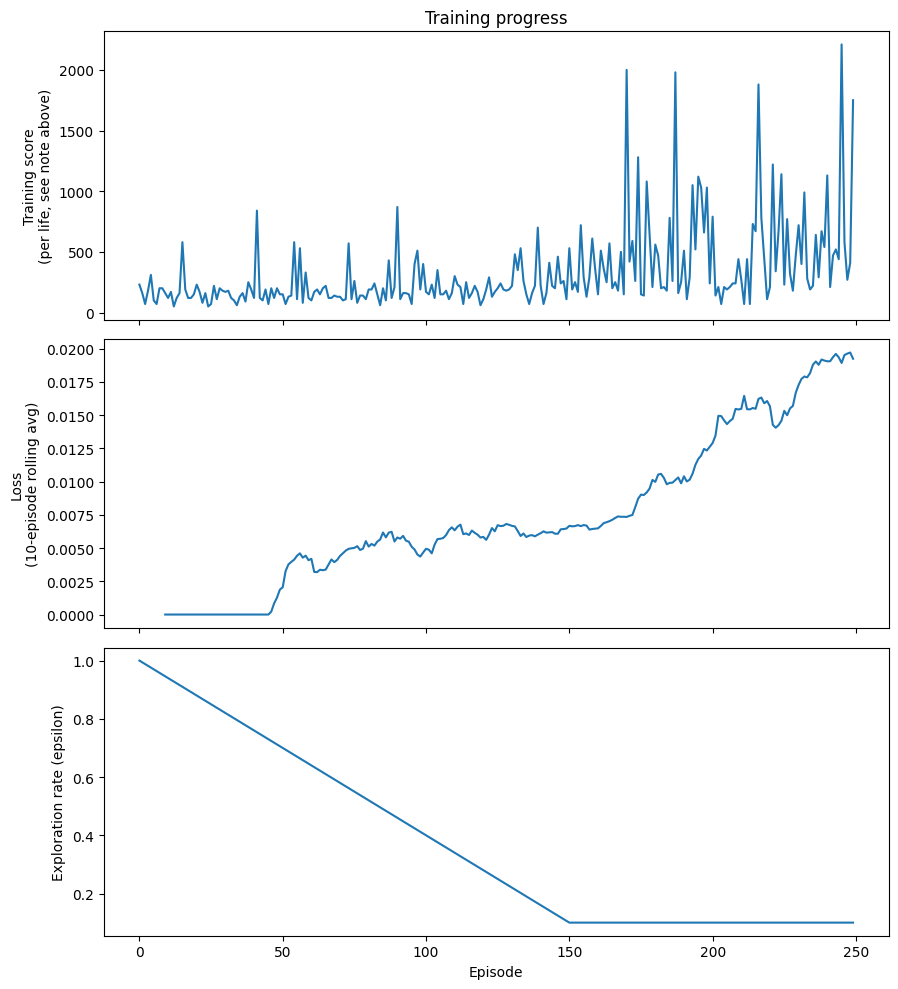

Saved plot to outputs/plots/training_curves.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(episode_scores)
axes[0].set_ylabel("Training score\n(per life, see note above)")
axes[0].set_title("Training progress")

# Raw per-episode loss is noisy; a rolling average is far more readable.
losses = np.array(episode_losses, dtype=float)
window = 10
if len(losses) >= window:
    rolling = np.convolve(np.nan_to_num(losses), np.ones(window) / window, mode="valid")
    axes[1].plot(range(window - 1, len(losses)), rolling)
else:
    axes[1].plot(losses)
axes[1].set_ylabel(f"Loss\n({window}-episode rolling avg)")

axes[2].plot(episode_epsilons)
axes[2].set_ylabel("Exploration rate (epsilon)")
axes[2].set_xlabel("Episode")

plt.tight_layout()
plot_path = os.path.join(PLOT_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved plot to", plot_path)


## Next steps: getting these results into the GitHub repo

1. **File → Download → Download .ipynb** — save this executed notebook (with all outputs visible) into the local repo folder, replacing the empty starter notebook.
2. Run the cell below to zip up the `outputs/` folder (GIFs, checkpoints, plot), then download that zip from the Colab file browser (folder icon on the left).
3. Send both files back — I'll unzip the outputs into the repo, fill in the actual numbers in `README.md`, and push everything to GitHub.


In [13]:
import shutil
shutil.make_archive("outputs", "zip", OUTPUT_DIR)
print("Created outputs.zip - download it from the Colab file browser (folder icon, left sidebar).")


Created outputs.zip - download it from the Colab file browser (folder icon, left sidebar).
